## Imports and Dataset Loading


In [1]:
import torch # Torch main framework
import torch.nn as nn # Used for getting the NN Layers
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creatning the objects
from torchsummary import summary # Visualize the model layers and number of parameters
from sklearn.model_selection import train_test_split # Split the dataset (train, validation, test)
from sklearn.metrics import accuracy_score # Calculate the testing Accuracy
import matplotlib.pyplot as plt # Plotting the training progress at the end
import pandas as pd # Data reading and preprocessing
import numpy as np # Mathematical operations

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [2]:
import torch
print(torch.__version__)            # PyTorch version
print(torch.version.cuda)           # CUDA version PyTorch was built with
print(torch.cuda.is_available())    # Should be True if CUDA works
print(torch.cuda.device_count())    # Number of GPUs detected
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.7.1+cu128
12.8
True
1
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
data_df = pd.read_csv('riceClassification.csv') # Read the CSV file
original_df = pd.read_csv('riceClassification.csv') # Read the CSV file

In [4]:
data_df.head() # Display the first 5 rows of the dataframe

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
data_df.shape

(18185, 12)

In [6]:
data_df.isnull().sum() # Check for null values

id                 0
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64

In [7]:
# Dropping id column as it is not required
data_df = data_df.drop(columns=['id'])

In [8]:
data_df.head() # Display the first 5 rows of the dataframe

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [9]:
print("Output Possible Classes: ", data_df['Class'].unique())

Output Possible Classes:  [1 0]


## Data Preprocessing

#### Normalization of data as all the features are not in the same range

In [10]:

for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].abs().max() # Divide by the maximum of the column which will make max value of each column is 1
data_df.head()
     

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


### Data Splitting

In [11]:
# Data Splitting
X = np.array(data_df.iloc[:,:-1]) # Get the inputs, all rows and all columns except last column (output)
Y = np.array(data_df.iloc[:, -1]) # Get the ouputs, all rows and last column only (output column)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3) # Create the training split
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5) # Create the validation split

print("Training set is: ", X_train.shape[0], " rows which is ", round(X_train.shape[0]/data_df.shape[0],4)*100, "%") # Print training shape
print("Validation set is: ",X_val.shape[0], " rows which is ", round(X_val.shape[0]/data_df.shape[0],4)*100, "%") # Print validation shape
print("Testing set is: ",X_test.shape[0], " rows which is ", round(X_test.shape[0]/data_df.shape[0],4)*100, "%") # Print testing shape

Training set is:  12729  rows which is  70.0 %
Validation set is:  2728  rows which is  15.0 %
Testing set is:  2728  rows which is  15.0 %


## Dataset Object

Now we will create the dataset object. This part is not complex but its a bit tricky. We need to convert our dataset to PyTorch Dataset object as it will be more efficient during training, you can use the dataset as its, but lets keep things professional and efficient. First we define our class that will be taking the main Dataset class with the concept of inheritance. Let's make the concept simpler. There is a big class that PyTorch, this class has several functions inside it, we will recreate that class and modify some functions to match our needs.

In the cell below, we rebuilt the constructor function which is `__init__`. We put X and Y as a parameters to this function which are the inputs and outputs respectively, then inside the function we define the inputs and converting it to tensors, then converting the outputs to tensors and we make the numbers as a `float32` Additionally, we moved all our data to cuda device. Then we modified the `__len__` and the `__getitem__` to match our needs which gets the specific length/shape of the data, and the data of specific row in our data respectively.

The current X and Y are numpy arrays, we need to convert them to tensors as PyTorch works with tensors. We can do this using `torch.tensor()` function and to load the data to cuda device we can use `.to(device)` function.

In [12]:
class dataset(Dataset): # Create a custom dataset class by inheriting the Dataset class of torch
    def __init__(self, X, Y): # modify the init function of the class to take inputs and outputs in numpy array format in float32 format
        self.X = torch.tensor(X, dtype = torch.float32).to(device)
        self.Y = torch.tensor(Y, dtype = torch.float32).to(device)

    def __len__(self): # adding our own len function to return the length of the dataset
        return len(self.X)
    def __getitem__(self, index): # adding our own getitem function to return the input and output at a particular index
        return self.X[index], self.Y[index]

training_data = dataset(X_train, y_train) # Create the training, validation and testing dataset objects using new dataset class
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)
# now our data will have some additional functionalities of the Dataset class which we made

## Model Building

###  Training Hyper Parameters
Now we are setting the training hyperparameters, we defined some variables which are the batch size, number of training epochs, Hidden Neurons and learning rate.

In [13]:
BATCH_SIZE = 32
EPOCHS = 100
HIDDEN_NEURONS = 10
LR = 1e-3

### Data Loaders
This concept may seem complicated, but its very easy, PyTorch provides a class called DataLoader which allows us to create objects of it to simplify the training.

Dataloader is an object that we can loop through it to train according to batches. When we start training, it takes care of batching, shuffling, and parallel loading, The DataLoader automatically splits your dataset into mini-batches. When you loop over the DataLoader with `for batch in dataloader:`, it yields one batch at a time (usually a tuple (inputs, labels)) for training. This is more efficient than feeding the entire dataset at once, especially for large datasets.

In the next cell, we defined a dataloader for each of our data (training, validation and testing). We loop through each batch and do the training using for loop. This feeding the data in batches is more efficient and faster

In [14]:
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle= True)
validation_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle= True)
testing_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle= True)

### Model Class
Creating a model in PyTorch seems not very straight forward in the beggining, but if you understand how machine learning and deep learning works, it will be easy for you to understand PyTorch structure easily.

In the next cell we define a new class MyModel that inherits from nn.Module like we did for the dataset. Remember, in simple terms, we want to redefine some functions in the class to match our needs. In the constructor which is `__init__` and we give it the bert model. Then super`(MyModel, self).__init__()` This line calls the constructor of the parent class nn.Module to ensure it's properly initialized. Which means we have the original constructor together with our part of it!

Then, we create our layers, a linear layer which represents the input and having the input size of 10 which is the number of columns of the input and the output of the number of hidden neurons, next layer is the output layer which have the input of hidden neurons and one output since we have a binary classification. Finally we have the activation function which is the sigmoid. Our model is pretty simple and straight forward, we are using a simple dataset and we just want to see how PyTorch can be used to build that.

In the function forward, this function is the forward propagation of the model, how is the data flowing inside the model from the input to the output. This means we can control this completely. That's how PyTorch is so customizable! In the below cell, we define the flow as follows, starting by input layer and followed by the output layer then the activation layer.

In [15]:
class MyModel(nn.Module): # Create a custom model class by inheriting the nn.Module class of torch
    def __init__(self):

        super(MyModel, self).__init__() # Call the constructor of the parent class nn.Module to modify it to match our needs

        # Define the layers here
        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS) # Input layer, X.shape[1] is the number of features in the input data, output is the number
        # of neurons in the hidden layer 
        self.linear = nn.Linear(HIDDEN_NEURONS, 1) # input is the number of neurons in the hidden layer, output is 1 as its binary classification
        self.sigmoid = nn.Sigmoid() # Sigmoid activation function for output layer for binary classification

    def forward(self, x): #  place the defined layers in forward function to define the model architecture
        x = self.input_layer(x) # Input layer
        x = self.linear(x) # Hidden layer
        x = self.sigmoid(x) # Output layer with sigmoid activation function
        return x # return the output

### Model Creation
Now lets create our model and move it to the assigned device (cuda if you have GPU or the CPU if you don't have any GPUs). Additionally, we will print the a `summary` of the model using the function summary which will take our model and the input size.

In [16]:
model = MyModel().to(device) # Create the model and move it to the assigned device (cuda or cpu)
summary(model, (X.shape[1],)) # Print the model summary with input size as number of features in the input data

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


### Loss and Optimizer
In the next cell, we will create the loss function which will be Binary Cross entropy and the optimizer `Adam` which will take the model parameters/weights and the learning rate.

In [17]:
criterion = nn.BCELoss() # Binary Cross Entropy Loss for binary classification
optimizer = Adam(model.parameters(), lr= LR) # Adam optimizer with model parameters and learning rate, model.parameters() will get all the weights of the
# model which will be updated during training

## Model Training
We start by initializing the for loop with the specified number of epochs. But before that we define 4 lists and inside the loop we define another 4 variables.

### Variables:
* `total_acc_train`: here we will keep tracking of the training accuracy progress during each epoch, we calculate the accuracy during the batch size and we print it in the end for tracking the accuracy on each epoch.

* `total_loss_train`: here we will keep tracking of the training loss progress during each epoch, we calculate the accuracy during the batch size and we use the loss value to optimize and modify the model parameters.

* `total_acc_val`: here we will keep tracking of the validation accuracy progress during each epoch, we calculate the accuracy during the batch size and we print it in the end for tracking the accuracy on each epoch and help us know if there is any overfitting.

* `total_loss_val`: here we will keep tracking of the validation loss progress during each epoch, we calculate the accuracy during the batch size.

### Lists:
* `total_acc_train_plot`: We append the losses of the training accuracy to visualize them at the end.

* `total_loss_train_plot`: We append the losses of the training to visualize them at the end.

* `total_acc_validation_plot`: We append the losses of the validation accuracy to visualize them at the end.

* `total_loss_validation_plot`: We append the losses of the validation to visualize them at the end.

In [18]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

### Training
Then, we start to loop through the training dataloaders, we use the enumerate functionality to loop through data and indices at the same time. We are not using the indices here, In the second loop, we start by getting our data from the data loader, then we move the inputs and labels to the cuda device. We allow the model to make a prediction or what is called forward propagation, then we get the output of the model and compare it with our original output using the loss criteration. We use the squeeze function to modify the shape of the output and make it returns a tensor with all specified dimensions of input of size 1 removed. we add the loss amount to `total_loss_train`. Additionally, we get the accuracy by comparing the correct batch with the predicted batch and we add it to the total_acc_train. Then we do the `batch_loss.backward()` which makes the backpropagation and we use the optimizer to do a step on the weights using `optimizer.step()` and then we reset the optimizer gradients using `optimizer.zero_grad()` which is a very important step that has to be done before proceeding.

### Validation
After that we exit the batch loop (train dataloader loop) and we start with the validation. we are still in the same epoch. In side that we start by with `torch.no_grad()` which means that we need the model to do predicitons without being trained. We just need to see the validation preformance. Then we do the same steps which are predicting and calculating loss and accuracy and storing these values.

At the end we print after each epoch the epoch number, training loss, training accuracy, validation loss and validation accuracy. We use the printing of "=" signs just for making the printing output looks clean.

## Early Stopping
Early stopping is a technique used to prevent overfitting during the training of a machine learning model

In [19]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, mode='min', restore_best=True, path=None):
        """
        patience: epochs to wait without improvement
        min_delta: minimum change to qualify as an improvement
        mode: 'min' for loss, 'max' for accuracy/score
        restore_best: load best weights when stopping
        path: optional path to save the best state_dict
        """
        assert mode in ('min','max')
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best = restore_best
        self.path = path

        self.best = None
        self.num_bad_epochs = 0
        self.best_state = None
        self.stop = False

    def step(self, metric, model):
        if self.best is None:
            improved = True
        else:
            if self.mode == 'min':
                improved = (self.best - metric) > self.min_delta
            else:
                improved = (metric - self.best) > self.min_delta

        if improved:
            self.best = metric
            self.num_bad_epochs = 0
            if self.restore_best:
                self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if self.path is not None:
                import torch
                torch.save(model.state_dict(), self.path)
        else:
            self.num_bad_epochs += 1

        if self.num_bad_epochs >= self.patience:
            self.stop = True
        return self.stop

    def restore(self, model):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state)
        elif self.path is not None:
            import torch
            model.load_state_dict(torch.load(self.path))


In [20]:
early_stopper = EarlyStopping(
    patience=5,        # try 3–10 depending on noise
    min_delta=1e-4,    # required improvement
    mode='min',        # we monitor val loss
    restore_best=True, # bring back best weights
    path=None          # or e.g. "best_model.pt"
)

In [21]:
for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0
    ## Training and Validation
    for data in train_dataloader:

        inputs, labels = data # Get the inputs and labels from the dataloader

        prediction = model(inputs).squeeze(1) # Get the model prediction and remove the extra dimension using squeeze, extra dimension is there because  
        # output of model will be of shape (batch_size, 1) where we need (batch_size,) as while labels are of shape (batch_size,) and they dont have
        # that extra dimension, we need to match the shapes for calculating loss, now only one dimension is there which has predictions

        batch_loss = criterion(prediction, labels) # Calculate the loss using the criterion defined before

        total_loss_train += batch_loss.item() # Add the batch loss to the total training loss

        acc = ((prediction).round() == labels).sum().item() # Calculate the accuracy for the batch, round the predictions to get 0 or 1 and compare with
        # labels, then sum the correct predictions of the batch and get the item value, item value extracts the sum value from the tensor

        total_acc_train += acc # Add the batch accuracy to the total training accuracy

        batch_loss.backward()   # Backpropagation, calculate the gradients
        optimizer.step()    # Update the weights
        optimizer.zero_grad()   # Zero the gradients for the next batch

    ## Validation
    with torch.no_grad(): # No need to calculate gradients during validation, we just need the predictions
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item()

            acc = ((prediction).round() == labels).sum().item()

            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train/1000, 4)) # Divide by 1000 to make the loss values smaller for better visualization
    total_loss_validation_plot.append(round(total_loss_val/1000, 4)) # Divide by 1000 to make the loss values smaller for better visualization
    total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4)) # Calculate the training accuracy in percentage
    total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4)) # Calculate the validation accuracy in percentage

    print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/1000:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')
    # train loss is divided by 1000 to make the loss values smaller for better visualization
    print("="*50)

Epoch no. 1 Train Loss: 0.2383 Train Accuracy: 85.1756 Validation Loss: 0.0386 Validation Accuracy: 98.4604
Epoch no. 2 Train Loss: 0.1175 Train Accuracy: 98.0124 Validation Loss: 0.0156 Validation Accuracy: 98.9003
Epoch no. 3 Train Loss: 0.0541 Train Accuracy: 98.2874 Validation Loss: 0.0085 Validation Accuracy: 98.6804
Epoch no. 4 Train Loss: 0.0351 Train Accuracy: 98.3659 Validation Loss: 0.0061 Validation Accuracy: 99.0103
Epoch no. 5 Train Loss: 0.0275 Train Accuracy: 98.3895 Validation Loss: 0.0051 Validation Accuracy: 98.9736
Epoch no. 6 Train Loss: 0.0237 Train Accuracy: 98.4602 Validation Loss: 0.0042 Validation Accuracy: 99.0103
Epoch no. 7 Train Loss: 0.0214 Train Accuracy: 98.4524 Validation Loss: 0.0038 Validation Accuracy: 99.0103
Epoch no. 8 Train Loss: 0.0200 Train Accuracy: 98.5231 Validation Loss: 0.0035 Validation Accuracy: 99.0103
Epoch no. 9 Train Loss: 0.0192 Train Accuracy: 98.5466 Validation Loss: 0.0033 Validation Accuracy: 98.9736
Epoch no. 10 Train Loss: 0.0

## Testing
Now in this section, we will be testing our model, we will start the code by with `torch.no_grad():` which means that we are telling PyTorch that we don't want to train the model we will be using it only for testing. Then we will declare initial loss and accuracy as zeros, we will start by looping through the testing dataloader like we did before during training. Inside the loop, we got our data and we moved it to our GPU (cuda) and then we ran our model on the data and we got the predictions. After that we get the loss and then we add it to our overall loss, we do the same for accuracy, and finally we print the accuracy.

In [22]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss_test = criterion((prediction), labels)
    total_loss_test += batch_loss_test.item()
    acc = ((prediction).round() == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/X_test.shape[0])*100, 2)}%")

Accuracy Score is: 98.79%


## Plotting and Visualizations

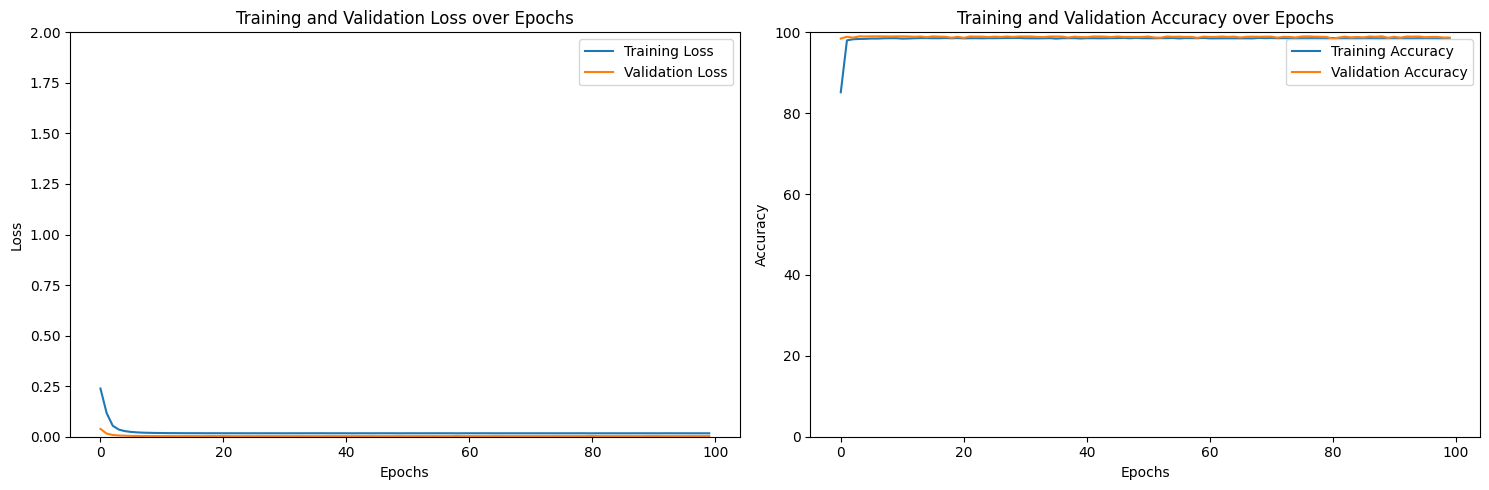

In [23]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()

## Inference
Using the model in inference mode, inference means making predictions like you are in production.

In [25]:
area = float(input("Area: "))/original_df['Area'].abs().max() # Normalize the input by dividing by the maximum value of that column in the original dataframe
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max() # Normalize the input by dividing by the maximum value of that column in the original dataframe
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("EquivDiameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("AspectRation: "))/original_df['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation] # Create the input list

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))

tensor([0.7590], device='cuda:0', grad_fn=<SigmoidBackward0>)
Class is:  1
